# 0. Cellule de recharchement

In [1]:
from pyspark.sql import SparkSession
from pyspark.ml.classification import RandomForestClassificationModel
from pyspark.sql import functions as F
import numpy as np
import pandas as pd

spark = SparkSession.builder \
    .appName("NetSentinel") \
    .config("spark.sql.extensions", "io.delta.sql.DeltaSparkSessionExtension") \
    .config("spark.sql.catalog.spark_catalog", "org.apache.spark.sql.delta.catalog.DeltaCatalog") \
    .config("spark.driver.memory", "25g") \
    .getOrCreate()

# recharger le parquet
df_final = spark.read.parquet("../data/processed/df_final.parquet")
train_df, test_df = df_final.randomSplit([0.8, 0.2], seed=42)

# feature_cols = toutes les colonnes sauf label et label_index
feature_cols = [c for c in df_final.columns if c not in ["label", "label_index", "features"]]

# recharger les 10 modèles
models = []
for i in range(10):
    m = RandomForestClassificationModel.load(f"../data/models/model_{i}")
    models.append(m)
    print(f"Modèle {i} rechargé")

print(f"Tout rechargé — {len(feature_cols)} features, {len(models)} modèles")

26/04/03 19:22:18 WARN SparkSession: Using an existing Spark session; only runtime SQL configurations will take effect.


Modèle 0 rechargé
Modèle 1 rechargé
Modèle 2 rechargé
Modèle 3 rechargé
Modèle 4 rechargé
Modèle 5 rechargé
Modèle 6 rechargé
Modèle 7 rechargé
Modèle 8 rechargé
Modèle 9 rechargé
Tout rechargé — 45 features, 10 modèles


# 1. Initialisation de la session Spark

In [2]:
# initialisation de la session Spark
from pyspark.sql import SparkSession

spark = SparkSession.builder.appName("NetSentinel - Batch Analysis").config("spark.driver.memory", "25g").getOrCreate()
print(spark.version)

3.5.5


26/04/03 12:16:06 WARN SparkSession: Using an existing Spark session; only runtime SQL configurations will take effect.


# 2. Concaténation des différents .csv

In [3]:
# importation de tous les .csv
import os

data_path = "../data"
df = spark.read.csv(data_path, header=True, inferSchema=True)

print(f"Nombre de lignes : {df.count()}")
print(f"Nombre de colonnes : {len(df.columns)}")

df.printSchema()

Nombre de lignes : 2607961
Nombre de colonnes : 122
root
 |-- flow_id: string (nullable = true)
 |-- timestamp: string (nullable = true)
 |-- src_ip: string (nullable = true)
 |-- src_port: string (nullable = true)
 |-- dst_ip: string (nullable = true)
 |-- dst_port: string (nullable = true)
 |-- protocol: string (nullable = true)
 |-- duration: string (nullable = true)
 |-- packets_count: string (nullable = true)
 |-- fwd_packets_count: string (nullable = true)
 |-- bwd_packets_count: string (nullable = true)
 |-- total_payload_bytes: string (nullable = true)
 |-- fwd_total_payload_bytes: string (nullable = true)
 |-- bwd_total_payload_bytes: string (nullable = true)
 |-- payload_bytes_max: string (nullable = true)
 |-- payload_bytes_min: string (nullable = true)
 |-- payload_bytes_mean: string (nullable = true)
 |-- payload_bytes_std: string (nullable = true)
 |-- payload_bytes_variance: string (nullable = true)
 |-- fwd_payload_bytes_max: double (nullable = true)
 |-- fwd_payload_by

### Vérification du déséquilibre des classes

- Le dataset source BCCC-CIC-IDS-2017 contient 2.6M de connexions réseau réparties sur 15 classes, Après analyse de la distribution des labels, nous avons décidé de filtrer le dataset pour ne garder que les 4 classes les plus représentées, afin de limiter le déséquilibre entre classes tout en conservant les types d'attaques les plus courants en entreprise

**info** : Note : le dataset source complet (2GB) est conservé et chargé intégralement par Spark,
le filtrage intervient uniquement en aval pour la phase d'entraînement du modèle.

In [4]:
df.groupBy("label").count().orderBy("count", ascending=False).show(truncate=False)

+-----------------+-------+
|label            |count  |
+-----------------+-------+
|Benign           |1786239|
|DoS_Hulk         |349240 |
|NULL             |169909 |
|Port_Scan        |161323 |
|DDoS_LOIT        |95733  |
|FTP-Patator      |9531   |
|DoS_GoldenEye    |8364   |
|DoS_Slowhttptest |6860   |
|SSH-Patator      |5949   |
|Botnet_ARES      |5508   |
|DoS_Slowloris    |5177   |
|Web_Brute_Force  |2734   |
|Web_XSS          |1358   |
|Web_SQL_Injection|24     |
|Heartbleed       |12     |
+-----------------+-------+



### Application des transformations citées ci-dessus

In [5]:
from pyspark.sql import functions as F

# définition des 10 labels qu'on veut garder
labels_conserved = [
    "Benign", "DoS_Hulk", "Port_Scan", "DDoS_LOIT",
    "FTP-Patator", "DoS_GoldenEye", "DoS_Slowhttptest",
    "SSH-Patator", "Botnet_ARES", "DoS_Slowloris"
]

# pour éviter le déséquilibre des classes, nous limitons le trafic normal a 100.000 lignes
benign_df = df.filter(F.col("label") == "Benign").limit(50000)

# pour éviter que les attaques avec peu de lignes soient écrasées nous allons également réduire Dos_Hulk + Port_Scan
dos_hulk_df = df.filter(F.col("label") == "DoS_Hulk").limit(50000)
port_scan_df = df.filter(F.col("label") == "Port_Scan").limit(50000)

# nous prenons toutes les attaques sauf le benign
attacks_df = df.filter(
    (F.col("label") != "Benign") &
    (F.col("label") != "DoS_Hulk") &
    (F.col("label") != "Port_Scan") &
    (F.col("label").isin(labels_conserved))
)

# nous collons les 2 df ensemble, le premier qui est limité à 100.000 et l'autre qui contient les attaques uniquement
df_balanced = benign_df.union(dos_hulk_df).union(port_scan_df).union(attacks_df)

# vérification - affiche le nombre de lignes par label
df_balanced.groupBy("label").count().orderBy("count", ascending=False).show()

+----------------+-----+
|           label|count|
+----------------+-----+
|       DDoS_LOIT|95733|
|          Benign|50000|
|        DoS_Hulk|50000|
|       Port_Scan|50000|
|     FTP-Patator| 9531|
|   DoS_GoldenEye| 8364|
|DoS_Slowhttptest| 6860|
|     SSH-Patator| 5949|
|     Botnet_ARES| 5508|
|   DoS_Slowloris| 5177|
+----------------+-----+



# 3. Exploration & Nettoyage des données

### 3.1 suppression des colonnes inutiles pour le ML

## Sélection des features

Après analyse des 116 features disponibles, nous avons décidé de réduire le nombre de features
à une quarantaine. Cette décision est motivée par deux raisons principales :

1. **Réduire le risque d'overfitting** : plus on a de features, plus le modèle risque d'apprendre
des patterns spécifiques au train set qui ne se généralisent pas bien.

2. **Réduire la consommation mémoire** : avec moins de features, on peut se permettre plus
d'arbres et plus de profondeur, ce qui améliore les performances globales.

### Features conservées et pourquoi

**Ports (src_port, dst_port)** → utiles pour détecter FTP-Patator (port 21) et SSH-Patator (port 22).

**Volume et débit** (duration, packets_count, fwd/bwd_packets_count, total_payload_bytes, bytes_rate,
fwd/bwd_bytes_rate, packets_rate, fwd/bwd_packets_rate, down_up_rate) → très révélateurs des attaques
DoS/DDoS qui génèrent un volume anormal de trafic.

**Taille des paquets** (payload_bytes_max/mean/std, fwd/bwd_payload_bytes_mean/std, avg_segment_size)
→ les attaques ont souvent des tailles de paquets très uniformes ou anormalement petites/grandes.

**Flags TCP** (fin, psh, urg, syn, ack, rst et leurs équivalents fwd) → critiques pour détecter les
attaques. Un SYN flood génère des milliers de flags SYN, un RST flood des milliers de RST.

**Timing entre paquets IAT** (packets_IAT_mean/std/max/min, fwd/bwd_packets_IAT_mean/std) → les
attaques automatisées ont des temps entre paquets très réguliers contrairement au trafic humain.

**Fenêtres TCP** (fwd/bwd_init_win_bytes) → la taille de fenêtre initiale est anormale lors d'un
SYN flood.

### Features supprimées et pourquoi

**Bulk features** (avg_fwd/bwd_bytes_per_bulk, fwd/bwd_bulk_state_count, etc.) → ces features
mesurent les transferts de données en rafale. Elles sont peu discriminantes pour nos types
d'attaques et très corrélées avec les features de volume déjà conservées.

**Header bytes** (total_header_bytes, max/min/mean/std_header_bytes et leurs équivalents fwd/bwd)
→ fortement corrélés avec les features de payload déjà conservées. Redondant.

**Flags ECE et CWR** (ece_flag_counts, cwr_flag_counts et leurs équivalents) → ces flags de
congestion réseau apparaissent très rarement et n'apportent pas d'information discriminante
pour nos classes d'attaques.

**Subflow features** (subflow_fwd/bwd_packets/bytes) → redondants avec packets_count et
total_payload_bytes déjà conservés.

**Active/Idle features** (active_min/max/mean/std, idle_min/max/mean/std) → ces features
mesurent les périodes d'activité et d'inactivité du flux. Peu pertinentes pour distinguer
les types d'attaques dans notre dataset.

In [6]:
cols_to_drop = [
    # identifiants inutiles
    "flow_id", "timestamp", "src_ip", "dst_ip",
    # header bytes redondants
    "total_header_bytes", "max_header_bytes", "min_header_bytes", "mean_header_bytes", "std_header_bytes",
    "fwd_total_header_bytes", "fwd_max_header_bytes", "fwd_min_header_bytes", "fwd_mean_header_bytes", "fwd_std_header_bytes",
    "bwd_total_header_bytes", "bwd_max_header_bytes", "bwd_min_header_bytes", "bwd_mean_header_bytes", "bwd_std_header_bytes",
    # bulk features redondants
    "avg_fwd_bytes_per_bulk", "avg_fwd_packets_per_bulk", "avg_fwd_bulk_rate",
    "avg_bwd_bytes_per_bulk", "avg_bwd_packets_bulk_rate", "avg_bwd_bulk_rate",
    "fwd_bulk_state_count", "fwd_bulk_total_size", "fwd_bulk_per_packet", "fwd_bulk_duration",
    "bwd_bulk_state_count", "bwd_bulk_total_size", "bwd_bulk_per_packet", "bwd_bulk_duration",
    # flags peu discriminants
    "ece_flag_counts", "cwr_flag_counts", "fwd_ece_flag_counts", "fwd_cwr_flag_counts",
    "bwd_fin_flag_counts", "bwd_psh_flag_counts", "bwd_urg_flag_counts", "bwd_ece_flag_counts",
    "bwd_syn_flag_counts", "bwd_ack_flag_counts", "bwd_cwr_flag_counts", "bwd_rst_flag_counts",
    # active/idle peu pertinents
    "active_min", "active_max", "active_mean", "active_std",
    "idle_min", "idle_max", "idle_mean", "idle_std",
    # subflow redondants
    "subflow_fwd_packets", "subflow_bwd_packets", "subflow_fwd_bytes", "subflow_bwd_bytes",
    # payload redondants
    "payload_bytes_min", "payload_bytes_variance",
    "fwd_payload_bytes_max", "fwd_payload_bytes_min", "fwd_payload_bytes_variance",
    "bwd_payload_bytes_max", "bwd_payload_bytes_min", "bwd_payload_bytes_variance",
    # IAT redondants
    "packet_IAT_total", "fwd_packets_IAT_max", "fwd_packets_IAT_min", "fwd_packets_IAT_total",
    "bwd_packets_IAT_max", "bwd_packets_IAT_min", "bwd_packets_IAT_total",
    # fwd flags redondants
    "fwd_fin_flag_counts", "fwd_psh_flag_counts", "fwd_urg_flag_counts",
]

df_clean = df_balanced.drop(*cols_to_drop)
print(f"Colonnes restantes : {len(df_clean.columns)}")

Colonnes restantes : 47


### 3.2 affichage des types de chaque colonne

In [7]:
for col, dtype in df_clean.dtypes:
    print(f"{col} : {dtype}")

src_port : string
dst_port : string
protocol : string
duration : string
packets_count : string
fwd_packets_count : string
bwd_packets_count : string
total_payload_bytes : string
fwd_total_payload_bytes : string
bwd_total_payload_bytes : string
payload_bytes_max : string
payload_bytes_mean : string
payload_bytes_std : string
fwd_payload_bytes_mean : double
fwd_payload_bytes_std : double
bwd_payload_bytes_mean : double
bwd_payload_bytes_std : double
fwd_avg_segment_size : double
bwd_avg_segment_size : double
avg_segment_size : double
fwd_init_win_bytes : int
bwd_init_win_bytes : int
bytes_rate : double
fwd_bytes_rate : double
bwd_bytes_rate : double
packets_rate : double
bwd_packets_rate : double
fwd_packets_rate : double
down_up_rate : double
fin_flag_counts : int
psh_flag_counts : int
urg_flag_counts : int
syn_flag_counts : int
ack_flag_counts : int
rst_flag_counts : int
fwd_syn_flag_counts : int
fwd_ack_flag_counts : int
fwd_rst_flag_counts : int
packets_IAT_mean : double
packet_IAT_s

### 3.3 conversion des dtypes nécessaire pour le ML
- Nous allons convertir les types (string) en types (double)

In [8]:
# liste des colonnes à convertir
string_to_double = [
    "src_port", "dst_port", "duration", "packets_count",
    "fwd_packets_count", "bwd_packets_count", "total_payload_bytes",
    "fwd_total_payload_bytes", "bwd_total_payload_bytes",
    "payload_bytes_max", "payload_bytes_mean", "payload_bytes_std"
]

for col_name in string_to_double:
    df_clean = df_clean.withColumn(col_name, F.col(col_name).cast("double"))

for col, dtype in df_clean.dtypes:
    print(f"{col} : {dtype}")

src_port : double
dst_port : double
protocol : string
duration : double
packets_count : double
fwd_packets_count : double
bwd_packets_count : double
total_payload_bytes : double
fwd_total_payload_bytes : double
bwd_total_payload_bytes : double
payload_bytes_max : double
payload_bytes_mean : double
payload_bytes_std : double
fwd_payload_bytes_mean : double
fwd_payload_bytes_std : double
bwd_payload_bytes_mean : double
bwd_payload_bytes_std : double
fwd_avg_segment_size : double
bwd_avg_segment_size : double
avg_segment_size : double
fwd_init_win_bytes : int
bwd_init_win_bytes : int
bytes_rate : double
fwd_bytes_rate : double
bwd_bytes_rate : double
packets_rate : double
bwd_packets_rate : double
fwd_packets_rate : double
down_up_rate : double
fin_flag_counts : int
psh_flag_counts : int
urg_flag_counts : int
syn_flag_counts : int
ack_flag_counts : int
rst_flag_counts : int
fwd_syn_flag_counts : int
fwd_ack_flag_counts : int
fwd_rst_flag_counts : int
packets_IAT_mean : double
packet_IAT_s

### 3.4 vérification des valeurs

In [9]:
# - F.col(c).isNull() → retourne True/False pour chaque ligne
# - .cast("int") → convertit True=1, False=0
# - F.sum() → additionne tous les 1 = nombre total de nulls
# - .alias(c) → renomme la colonne résultante avec le nom de la colonne originale

null_counts = df_clean.select([
    F.sum(F.col(c).isNull().cast("int")).alias(c)
    for c in df_clean.columns
])

# affichage vertical pour plus de clarté
null_counts.show(vertical=True)

26/04/03 12:16:50 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


-RECORD 0----------------------
 src_port                | 0   
 dst_port                | 0   
 protocol                | 0   
 duration                | 0   
 packets_count           | 0   
 fwd_packets_count       | 0   
 bwd_packets_count       | 0   
 total_payload_bytes     | 0   
 fwd_total_payload_bytes | 0   
 bwd_total_payload_bytes | 0   
 payload_bytes_max       | 0   
 payload_bytes_mean      | 0   
 payload_bytes_std       | 0   
 fwd_payload_bytes_mean  | 0   
 fwd_payload_bytes_std   | 0   
 bwd_payload_bytes_mean  | 0   
 bwd_payload_bytes_std   | 0   
 fwd_avg_segment_size    | 0   
 bwd_avg_segment_size    | 0   
 avg_segment_size        | 0   
 fwd_init_win_bytes      | 0   
 bwd_init_win_bytes      | 0   
 bytes_rate              | 0   
 fwd_bytes_rate          | 0   
 bwd_bytes_rate          | 0   
 packets_rate            | 0   
 bwd_packets_rate        | 0   
 fwd_packets_rate        | 0   
 down_up_rate            | 0   
 fin_flag_counts         | 0   
 psh_fla

**info** : nous décidons de supprimer la colonne 'protocol' parce qu'elle contenait des valeurs non numériques (TCP, UDP) qui sont devenues nulle après la conversion en double, presque l'entièreté de la colonne est vide, de plus le protocole est indirectement représenté par les flags TCP donc nous décidons de supprimer cette colonne

In [10]:
# suppression de la colonne 'protocol'
df_clean = df_clean.drop("protocol")

# vérification
print(f"Colonnes restantes : {len(df_clean.columns)}")

Colonnes restantes : 46


### 3.5 remplacer les valeurs infinies par null

- quand spark divise par 0 il génère des inf ou -inf et le ML ne sait pas gérer ça, nous remplaçons donc les valeurs inf et -inf par null

In [11]:
import math

# nous récupérons toutes les colonnes doubles
double_cols = [c for c, t in df_clean.dtypes if t == "double"]

# pour chaque colonne double, on remplace par inf, -inf par null
for c in double_cols:
    df_clean = df_clean.withColumn(c,
        F.when(F.col(c) == float("inf"), None)
        .when(F.col(c) == float("-inf"), None)
        .otherwise(F.col(c))
    )

print(f"Valeurs infinies remplacées par null OK !")

Valeurs infinies remplacées par null OK !


In [12]:
# maintenant que certaines valeurs ont été remplacées par NULL, nous allons les supprimer

df_clean = df_clean.dropna()

# vérification
print(f"Lignes restantes : {df_clean.count()}")
df_clean.groupBy("label").count().orderBy("count", ascending=False).show()

Lignes restantes : 287122


+----------------+-----+
|           label|count|
+----------------+-----+
|       DDoS_LOIT|95733|
|          Benign|50000|
|        DoS_Hulk|50000|
|       Port_Scan|50000|
|     FTP-Patator| 9531|
|   DoS_GoldenEye| 8364|
|DoS_Slowhttptest| 6860|
|     SSH-Patator| 5949|
|     Botnet_ARES| 5508|
|   DoS_Slowloris| 5177|
+----------------+-----+



---
# 4. MACHINE LEARNING

### 4.1 encodage du label, on va remplacer le nom des attaques par des chiffres style DDOS = 1 etc

In [13]:
from pyspark.ml.feature import StringIndexer, VectorAssembler

# utilisation de StringIndexer qui permet de transformer les labels texte en indice numériques
indexer = StringIndexer(inputCol="label", outputCol="label_index")
df_indexed = indexer.fit(df_clean).transform(df_clean)

# assembler toutes les features en un seul vecteur, parce que spark accepte uniquement 2 colonnes en entrée donc on met toutes les feat dans un vec
feature_cols = [c for c in df_indexed.columns if c not in ["label", "label_index"]]
assembler = VectorAssembler(inputCols=feature_cols, outputCol="features")
df_final = assembler.transform(df_indexed)

# split 80 / 20
train_df, test_df = df_final.randomSplit([0.8, 0.2], seed=42)

print(f"Train : {train_df.count()}")
print(f"Test : {test_df.count()}")

Train : 229655


Test : 57467


### 4.2.1 sauvegarde intermédiaire .parquet

In [14]:
import pandas as pd
heartbleed = pd.read_csv('../data/heartbleed.csv', sep=',', header=None, na_values=[''], quotechar='"')
heartbleed

,0,1,2,3,4,5,6,7,8,9,...,112,113,114,115,116,117,118,119,120,121
0,flow_id,timestamp,src_ip,src_port,dst_ip,dst_port,protocol,duration,packets_count,fwd_packets_count,...,bwd_packets_IAT_mean,bwd_packets_IAT_std,bwd_packets_IAT_max,bwd_packets_IAT_min,bwd_packets_IAT_total,subflow_fwd_packets,subflow_bwd_packets,subflow_fwd_bytes,subflow_bwd_bytes,label
1,172.16.0.1_44904_192.168.10.51_444_TCP_2017-07...,2017-07-05 13:52:55.240247,172.16.0.1,44904,192.168.10.51,444,TCP,5.042543888092041,9,4,...,1.26062423,1.29041137,2.9199910163879395,0.0003328323364257,5.042496919631958,2.0,2.5,258.5,258.5,Heartbleed
2,172.16.0.1_44906_192.168.10.51_444_TCP_2017-07...,2017-07-05 13:53:13.871638,172.16.0.1,44906,192.168.10.51,444,TCP,5.011056900024414,9,4,...,1.25275671,1.33263071,3.151447057723999,0.0001039505004882,5.011026859283447,2.0,2.5,258.5,258.5,Heartbleed
3,172.16.0.1_44990_192.168.10.51_444_TCP_2017-07...,2017-07-05 14:09:50.636311,172.16.0.1,44990,192.168.10.51,444,TCP,5.027477979660034,9,4,...,1.25685453,1.27491374,2.8250529766082764,0.0003139972686767,5.02741813659668,2.0,2.5,258.5,258.5,Heartbleed
4,172.16.0.1_44994_192.168.10.51_444_TCP_2017-07...,2017-07-05 14:10:02.843894,172.16.0.1,44994,192.168.10.51,444,TCP,5.016771078109741,9,4,...,1.25419176,1.66055437,4.0482470989227295,0.0002131462097167,5.0167670249938965,4.0,5.0,517.0,517.0,Heartbleed
5,172.16.0.1_44904_192.168.10.51_444_TCP_2017-07...,2017-07-05 13:53:00.283187,172.16.0.1,44904,192.168.10.51,444,TCP,0.0,1,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Heartbleed
6,172.16.0.1_44906_192.168.10.51_444_TCP_2017-07...,2017-07-05 13:53:18.883144,172.16.0.1,44906,192.168.10.51,444,TCP,0.0,1,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Heartbleed
7,172.16.0.1_44912_192.168.10.51_444_TCP_2017-07...,2017-07-05 13:59:47.380171,172.16.0.1,44912,192.168.10.51,444,TCP,6.620403051376343,11,5,...,1.3240756,1.26072902,3.303910970687866,4.506111145019531e-05,6.620378017425537,1.6666666666666667,2.0,4.0,4.0,Heartbleed
8,172.16.0.1_44992_192.168.10.51_444_TCP_2017-07...,2017-07-05 14:09:54.892192,172.16.0.1,44992,192.168.10.51,444,TCP,5.778207063674927,11,5,...,1.15563159,0.75676068,2.3895909786224365,4.00543212890625e-05,5.778157949447632,1.25,1.5,3.75,3.75,Heartbleed
9,172.16.0.1_44990_192.168.10.51_444_TCP_2017-07...,2017-07-05 14:09:55.664158,172.16.0.1,44990,192.168.10.51,444,TCP,0.0,1,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Heartbleed


In [15]:
# afin de respecter les bonnes pratiques (conseillées) nous allons sauvegarder nos étapes intermédiaires en parquet

df_final.write.parquet("../data/processed/df_final.parquet", mode="overwrite")
print("Sauvegarde Parquet OK !")

# pour reprendre à ce niveau, run : df_final = spark.read.parquet("../data/processed/df_final.parquet")

Sauvegarde Parquet OK !


In [16]:
df_final = spark.read.parquet("../data/processed/df_final.parquet")
train_df, test_df = df_final.randomSplit([0.8, 0.2], seed=42)

### 4.2.2 cross validation

In [17]:
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
from pyspark.ml.classification import RandomForestClassifier

# 1. on réutilise les paramètres (50 arbres, depth 10)
rf_cv = RandomForestClassifier(numTrees=50, maxDepth=10, labelCol="label_index", seed=42)

# 2. configuration (3 découpes, F1-score)
cv = CrossValidator(
    estimator=rf_cv,
    estimatorParamMaps=ParamGridBuilder().build(),
    evaluator=MulticlassClassificationEvaluator(labelCol="label_index", metricName="f1"),
    numFolds=3
)

# 3. lancement
cv_model = cv.fit(train_df)

print(f"F1-Score moyen (CV) : {cv_model.avgMetrics[0]:.4f}")

26/04/03 12:20:04 WARN DAGScheduler: Broadcasting large task binary with size 1260.4 KiB
26/04/03 12:20:04 WARN DAGScheduler: Broadcasting large task binary with size 1878.5 KiB
26/04/03 12:20:05 WARN DAGScheduler: Broadcasting large task binary with size 2.6 MiB
26/04/03 12:20:07 WARN DAGScheduler: Broadcasting large task binary with size 3.4 MiB
26/04/03 12:20:10 WARN DAGScheduler: Broadcasting large task binary with size 2.6 MiB
26/04/03 12:20:17 WARN DAGScheduler: Broadcasting large task binary with size 1277.0 KiB
26/04/03 12:20:18 WARN DAGScheduler: Broadcasting large task binary with size 1925.1 KiB
26/04/03 12:20:19 WARN DAGScheduler: Broadcasting large task binary with size 2.6 MiB
26/04/03 12:20:20 WARN DAGScheduler: Broadcasting large task binary with size 3.5 MiB
26/04/03 12:20:24 WARN DAGScheduler: Broadcasting large task binary with size 2.6 MiB
26/04/03 12:20:30 WARN DAGScheduler: Broadcasting large task binary with size 1253.0 KiB
26/04/03 12:20:31 WARN DAGScheduler: Br

F1-Score moyen (CV) : 0.9827


### 4.3 train du modèle (random forest)

In [18]:
from pyspark.ml.classification import RandomForestClassifier

models = []
n_models = 10
trees_per_model = 50

for i in range(n_models):
    print(f"Entraînement modèle {i+1}/{n_models}...")
    rf = RandomForestClassifier(
        numTrees=trees_per_model,
        maxDepth=10,
        labelCol="label_index",
        featuresCol="features",
        seed=i
    )
    model_i = rf.fit(train_df)
    models.append(model_i)
    print(f"  Modèle {i+1} entraîné")

print("Tous les modèles entraînés !")

Entraînement modèle 1/10...


26/04/03 12:20:56 WARN DAGScheduler: Broadcasting large task binary with size 1281.8 KiB
26/04/03 12:20:57 WARN DAGScheduler: Broadcasting large task binary with size 1967.2 KiB
26/04/03 12:20:59 WARN DAGScheduler: Broadcasting large task binary with size 2.7 MiB
26/04/03 12:21:00 WARN DAGScheduler: Broadcasting large task binary with size 3.6 MiB


  Modèle 1 entraîné
Entraînement modèle 2/10...


26/04/03 12:21:08 WARN DAGScheduler: Broadcasting large task binary with size 1216.3 KiB
26/04/03 12:21:09 WARN DAGScheduler: Broadcasting large task binary with size 1830.4 KiB
26/04/03 12:21:10 WARN DAGScheduler: Broadcasting large task binary with size 2.5 MiB
26/04/03 12:21:11 WARN DAGScheduler: Broadcasting large task binary with size 3.4 MiB


  Modèle 2 entraîné
Entraînement modèle 3/10...


...

  Modèle 8 entraîné
Entraînement modèle 9/10...


26/04/03 12:22:35 WARN DAGScheduler: Broadcasting large task binary with size 1234.7 KiB
26/04/03 12:22:36 WARN DAGScheduler: Broadcasting large task binary with size 1874.9 KiB
26/04/03 12:22:37 WARN DAGScheduler: Broadcasting large task binary with size 2.6 MiB
26/04/03 12:22:38 WARN DAGScheduler: Broadcasting large task binary with size 3.4 MiB


  Modèle 9 entraîné
Entraînement modèle 10/10...


26/04/03 12:22:46 WARN DAGScheduler: Broadcasting large task binary with size 1258.9 KiB
26/04/03 12:22:47 WARN DAGScheduler: Broadcasting large task binary with size 1903.3 KiB
26/04/03 12:22:48 WARN DAGScheduler: Broadcasting large task binary with size 2.6 MiB
26/04/03 12:22:50 WARN DAGScheduler: Broadcasting large task binary with size 3.5 MiB


  Modèle 10 entraîné
Tous les modèles entraînés !


### 4.4 évaluation

In [19]:
from pyspark.sql import functions as F
import pandas as pd

# prédictions de chaque modèle
all_preds = test_df
for i, m in enumerate(models):
    all_preds = m.transform(all_preds) \
        .withColumnRenamed("prediction", f"pred_{i}") \
        .drop("rawPrediction", "probability")

# vote majoritaire
pred_cols = [f"pred_{i}" for i in range(n_models)]
all_preds = all_preds.withColumn(
    "final_prediction",
    F.array_sort(F.array(*[F.col(c) for c in pred_cols]))[n_models // 2]
)

# évaluation
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

accuracy = MulticlassClassificationEvaluator(labelCol="label_index", predictionCol="final_prediction", metricName="accuracy").evaluate(all_preds)
f_score = MulticlassClassificationEvaluator(labelCol="label_index", predictionCol="final_prediction", metricName="f1").evaluate(all_preds)

print(f"Accuracy : {accuracy:.4f}")
print(f"F1-Score : {f_score:.4f}")

26/04/03 12:22:52 WARN DAGScheduler: Broadcasting large task binary with size 25.4 MiB
26/04/03 12:23:01 WARN DAGScheduler: Broadcasting large task binary with size 25.4 MiB


Accuracy : 0.9885
F1-Score : 0.9881


In [20]:
import pandas as pd
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

# matrice de confusion
conf_matrix = all_preds.groupBy("label_index", "final_prediction").count().orderBy("label_index", "final_prediction")

# conversion en pandas pour afficher
conf_df = conf_matrix.toPandas()

# Récupérer le mapping index -> nom d'attaque
labels = ["Benign", "DDoS_LOIT", "DoS_Hulk", "Port_Scan",
          "FTP-Patator", "DoS_GoldenEye", "DoS_Slowhttptest",
          "SSH-Patator", "Botnet_ARES", "DoS_Slowloris"]
print("Mapping :")
for i, l in enumerate(labels):
    print(f"  {i} → {l}")

print("\nMatrice de confusion brute :")
print(conf_df)

26/04/03 12:23:10 WARN DAGScheduler: Broadcasting large task binary with size 25.4 MiB
26/04/03 12:23:18 WARN DAGScheduler: Broadcasting large task binary with size 25.4 MiB
26/04/03 12:23:19 WARN DAGScheduler: Broadcasting large task binary with size 25.4 MiB
26/04/03 12:23:21 WARN DAGScheduler: Broadcasting large task binary with size 25.4 MiB


Mapping :
  0 → Benign
  1 → DDoS_LOIT
  2 → DoS_Hulk
  3 → Port_Scan
  4 → FTP-Patator
  5 → DoS_GoldenEye
  6 → DoS_Slowhttptest
  7 → SSH-Patator
  8 → Botnet_ARES
  9 → DoS_Slowloris

Matrice de confusion brute :
    label_index  final_prediction  count
0           0.0               0.0  19097
1           0.0               1.0      2
2           1.0               1.0   9848
3           1.0               2.0     31
4           1.0               5.0      1
5           1.0               6.0      1
6           1.0               8.0      7
7           2.0               1.0      4
8           2.0               2.0   9973
9           2.0               5.0      3
10          2.0               6.0     10
11          3.0               1.0      9
12          3.0               3.0  10075
13          4.0               4.0   1931
14          4.0               7.0      3
15          5.0               1.0     65
16          5.0               2.0     59
17          5.0               5.0   1572
18  

### Rappel -> prochaine étape :
- faire une matrice de confusion
- regardez, les features les plus importantes (faire quelques graphiques)
- quelques plots (distributions des attaques, métriques visuelle)
- faire le vrai dashboard

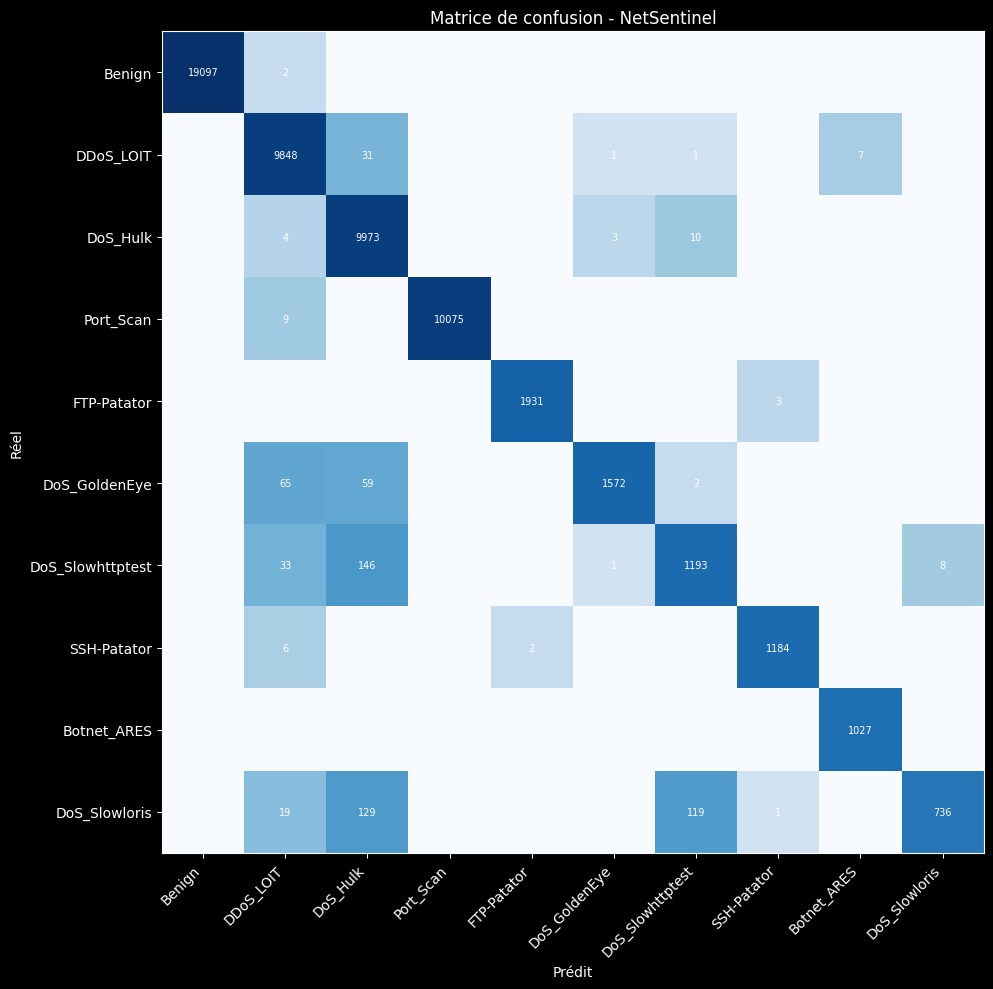

In [21]:
# Matrice de confusion

%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LogNorm

label_names = ["Benign", "DDoS_LOIT", "DoS_Hulk", "Port_Scan",
               "FTP-Patator", "DoS_GoldenEye", "DoS_Slowhttptest",
               "SSH-Patator", "Botnet_ARES", "DoS_Slowloris"]

matrix = np.zeros((10, 10), dtype=int)
for _, row in conf_df.iterrows():
    i = int(row["label_index"])
    j = int(row["final_prediction"])
    matrix[i][j] = int(row["count"])

matrix_plot = np.where(matrix == 0, 0.1, matrix)

fig, ax = plt.subplots(figsize=(12, 10))
ax.imshow(matrix_plot, cmap="Blues", norm=LogNorm())
ax.set_xticks(range(10))
ax.set_yticks(range(10))
ax.set_xticklabels(label_names, rotation=45, ha="right")
ax.set_yticklabels(label_names)
ax.set_xlabel("Prédit")
ax.set_ylabel("Réel")
ax.set_title("Matrice de confusion - NetSentinel")

for i in range(10):
    for j in range(10):
        if matrix[i][j] > 0:
            ax.text(j, i, str(matrix[i][j]), ha="center", va="center", fontsize=7)

plt.tight_layout()
plt.savefig("../data/confusion_matrix.png", dpi=150)
plt.show()
plt.close()

### 4.6 Sauvegarde des modèles

In [22]:
# sauvegarde de chaque modèle
for i, m in enumerate(models):
    m.write().overwrite().save(f"../data/models/model_{i}")
    print(f"Modèle {i} sauvegardé")

Modèle 0 sauvegardé
Modèle 1 sauvegardé
Modèle 2 sauvegardé
Modèle 3 sauvegardé
Modèle 4 sauvegardé
Modèle 5 sauvegardé
Modèle 6 sauvegardé
Modèle 7 sauvegardé
Modèle 8 sauvegardé
Modèle 9 sauvegardé


---

# 5 Impurity-based Feature Importance

- dans un arbre de décision, à chaque noeud on fait une coupure sur une feature. Cette coupure va réduire l'impureté (le mélange des classes) dans des sous groupes

- donc en gros, si une feature est souvent utilisée pour des coupures qui séparent bien les classes alors son importance est élevée

**info** : étant donné que j'ai 10 modèles ici, je fais le calcul pour chaque modèle puis je moyenne, j'obtiens une estimation très stable

In [23]:
import numpy as np
import pandas as pd

# récupération de l'importance moyenne de chaque feature pour chaque modèle
importances = np.mean([m.featureImportances.toArray() for m in models], axis=0)

# création d'un dataframe 2 colonnes avec le nom de la features et son importance
feature_importance = pd.DataFrame({
    "feature": feature_cols,
    "importance": importances
}).sort_values("importance", ascending=False)

# affiche les 20 features les plus importantes
print(feature_importance.head(20))

                    feature  importance
20       bwd_init_win_bytes    0.060440
41     fwd_packets_IAT_mean    0.055499
9         payload_bytes_max    0.050821
43     bwd_packets_IAT_mean    0.048593
39           packet_IAT_max    0.043507
17     bwd_avg_segment_size    0.038709
11        payload_bytes_std    0.036286
19       fwd_init_win_bytes    0.035074
26         fwd_packets_rate    0.032331
37         packets_IAT_mean    0.032138
33          rst_flag_counts    0.031939
7   fwd_total_payload_bytes    0.030784
1                  dst_port    0.030043
15    bwd_payload_bytes_std    0.028707
16     fwd_avg_segment_size    0.027443
6       total_payload_bytes    0.027423
13    fwd_payload_bytes_std    0.026946
24             packets_rate    0.024476
25         bwd_packets_rate    0.023802
12   fwd_payload_bytes_mean    0.022045


### Analyse des résultats

---

**bwd_init_win_bytes** : la feature les plus importante, c'est la taille des fenêtres TCP que le serveur va proposer au client au début d'une connexion, en traffic normal c'est une valeur qui est relativement grande, dans une attaque SYN flood, l'attaquant envoie des milliers de connexions sans jamais répondre, la fenêtre reste anormalement petite ou nulle, le modèle l'a bien appris !

**fwd_packets_IAT_mean** : IAT est l'inter arrival time c'est à dire le temps entre deux paquets, il faut savoir qu'un humain qui navigue de façon normale sur le web va envoyer des paquets de façon très irrégulière, alors qu'un script d'attaque va envoyer des paquets de façon hyper régulière (comme une machine), le modèle détecte bien cette régularité anormale

**payload_bytes_max** : la taille maximale d'un paquet dans le flux, certaines attaques envoient des paquets très petits pour saturer le serveur et parfois des très gros, le modèle repère les valeurs anormales

**rst_flag_counts** : le flag RST (RESET) c'est une coupure soudaine de la connexion TCP, en traffic normal il apparait très peu, dans certaines attaques l'attaquant va ouvrir et fermer beaucoup de connexion rapidement --> ce qui donne beaucoup de RST, le modèle a également appris ça

**bwd_packets_IAT_mean** : même principe que fwd_packets_IAT_mean mais cette fois c'est le temps entre les paquets que le serveur renvoie, dans une attaque DoS le serveur répond de façon chaotique ou pas du tout, le modèle détecte ce comportement anormal côté serveur

**packet_IAT_max** : c'est le temps maximum entre deux paquets dans tout le flux, un humain normal fait des pauses longues (il lit, il réfléchit), un script d'attaque lui va maintenir un rythme régulier sans grandes pauses, le modèle repère cette absence de pauses naturelles

**bwd_avg_segment_size** : la taille moyenne des segments reçus côté serveur, certaines attaques comme Slowloris envoient des segments minuscules exprès pour saturer le serveur sans déclencher d'alarme, d'autres comme DoS_Hulk envoient des segments énormes, le modèle détecte les deux extrêmes

**payload_bytes_std** : l'écart-type de la taille des paquets, un écart-type faible = les paquets ont tous à peu près la même taille = comportement de machine = attaque, un écart-type élevé = tailles très variées = comportement humain normal, c'est un signal très discriminant

**fwd_init_win_bytes** : même logique que bwd_init_win_bytes mais côté client cette fois, c'est la fenêtre TCP que le client propose au serveur au début de la connexion, anormale dans beaucoup de types d'attaques

**fwd_packets_rate / bwd_packets_rate / packets_rate** : le débit en paquets par seconde dans les deux sens et au total, un DDoS génère des milliers de paquets par seconde, c'est un des signaux les plus évidents et le modèle l'a bien capté

**dst_port** : le port de destination de la connexion, FTP-Patator cible systématiquement le port 21, SSH-Patator le port 22, le modèle a appris ces associations port → type d'attaque

**wd_payload_bytes_std / fwd_payload_bytes_std** : l'écart-type des tailles de paquets dans chaque sens séparément, même logique que payload_bytes_std mais avec plus de granularité, utile pour détecter des attaques asymétriques

**fwd_avg_segment_size / bwd_avg_segment_size** : la taille moyenne des segments dans chaque sens, complète le payload_bytes_max en donnant une vue globale plutôt que juste le maximum

**total_payload_bytes / fwd_total_payload_bytes** : le volume total de données échangées dans le flux, un DoS envoie énormément de données pour saturer le serveur, c'est un signal de volume très direct

**fwd_payload_bytes_mean** : la taille moyenne des paquets envoyés par le client, complète les autres features de taille pour donner une image complète du comportement du flux

### 5.1 Métriques par classe

In [3]:
labels_list = ["Benign", "DDoS_LOIT", "DoS_Hulk", "Port_Scan",
               "FTP-Patator", "DoS_GoldenEye", "DoS_Slowhttptest",
               "SSH-Patator", "Botnet_ARES", "DoS_Slowloris"]

per_class = []
for label_idx in range(10):
    # vrais positifs
    tp = conf_df[(conf_df["label_index"] == label_idx) & (conf_df["final_prediction"] == label_idx)]["count"].sum()
    # faux négatifs = réels mais mal prédits
    fn = conf_df[(conf_df["label_index"] == label_idx) & (conf_df["final_prediction"] != label_idx)]["count"].sum()
    # faux positifs = autres classes prédites comme cette classe
    fp = conf_df[(conf_df["label_index"] != label_idx) & (conf_df["final_prediction"] == label_idx)]["count"].sum()

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

    per_class.append({
        "label": labels_list[label_idx],
        "precision": round(precision * 100, 2),
        "recall": round(recall * 100, 2),
        "f1": round(f1 * 100, 2),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp)
    })

per_class_df = pd.DataFrame(per_class)
print(per_class_df)

              label  precision  recall     f1   fp   fn     tp
0            Benign     100.00   99.99  99.99    0    2  19097
1         DDoS_LOIT      98.62   99.60  99.10  138   40   9848
2          DoS_Hulk      96.47   99.83  98.12  365   17   9973
3         Port_Scan     100.00   99.91  99.96    0    9  10075
4       FTP-Patator      99.90   99.84  99.87    2    3   1931
5     DoS_GoldenEye      99.68   92.58  96.00    5  126   1572
6  DoS_Slowhttptest      90.04   86.39  88.17  132  188   1193
7       SSH-Patator      99.66   99.33  99.50    4    8   1184
8       Botnet_ARES      99.32  100.00  99.66    7    0   1027
9     DoS_Slowloris      98.92   73.31  84.21    8  268    736


# 6 Export pour dashboard

In [24]:
import os
import pandas as pd

# 1. feature importances
spark.createDataFrame(feature_importance).write.format("delta").mode("overwrite").save("../data/dashboard/feature_importance")

# 2. label counts
label_counts = spark.read.parquet("../data/processed/df_final.parquet") \
    .groupBy("label").count() \
    .orderBy("count", ascending=False)
label_counts.write.format("delta").mode("overwrite").save("../data/dashboard/label_counts")

# 3. matrice de confusion
spark.createDataFrame(conf_df).write.format("delta").mode("overwrite").save("../data/dashboard/conf_matrix")

# 4. métriques globales
metrics = pd.DataFrame({
    "metric": ["Accuracy", "Precision", "Recall", "F1-Score"],
    "value": [0.9885, 0.9888, 0.9885, 0.9881]
})
spark.createDataFrame(metrics).write.format("delta").mode("overwrite").save("../data/dashboard/metrics")

# 5. taux de détection
detection_rates = []
for label_idx in range(10):
    total = conf_df[conf_df["label_index"] == label_idx]["count"].sum()
    correct = conf_df[(conf_df["label_index"] == label_idx) & (conf_df["final_prediction"] == label_idx)]["count"].sum()
    rate = correct / total * 100 if total > 0 else 0
    detection_rates.append({"label": labels[label_idx], "taux": round(rate, 2)})
spark.createDataFrame(pd.DataFrame(detection_rates)).write.format("delta").mode("overwrite").save("../data/dashboard/detection_rates")

# 6. métriques par classe
spark.createDataFrame(per_class_df).write.format("delta").mode("overwrite").save("../data/dashboard/per_class_metrics")

print("Export Delta OK")

Export Delta OK
